Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embeddings shape: (10, 384)


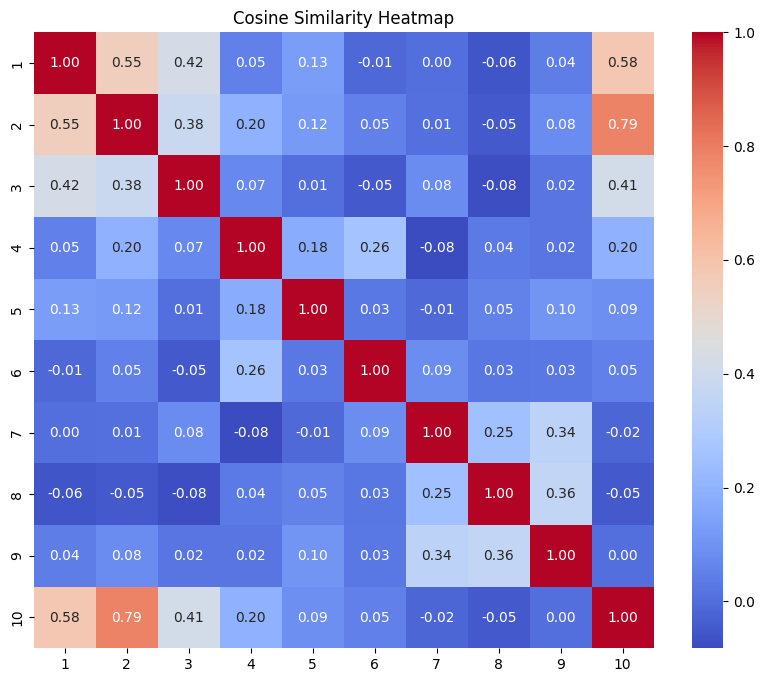

In [ ]:
!pip install -q sentence-transformers
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the model
model = SentenceTransformer('all-MiniLM-L6-v2')

sentences = [
    # Cricket
    "The batsman scored a century in the final match.",
    "The bowler took five wickets in the first innings.",
    "The cricket match was interrupted by rain.",

    # Cooking
    "I chopped the onions and sautéed them until golden.",
    "Baking a chocolate cake requires precise measurements.",
    "The recipe called for marinating the chicken overnight.",

    # Cybersecurity
    "A firewall protects a network from unauthorized access.",
    "Phishing emails are a common cybersecurity threat.",
    "Encryption is essential to secure sensitive data.",

    # Extra / query
    "The bowler took three wickets in one over."
]

embeddings = model.encode(sentences)
print("Embeddings shape:", embeddings.shape)

cos_sim = cosine_similarity(embeddings)

plt.figure(figsize=(10,8))
sns.heatmap(cos_sim, annot=True, fmt=".2f", cmap="coolwarm", xticklabels=range(1,11), yticklabels=range(1,11))
plt.title("Cosine Similarity Heatmap")
plt.show()

query = "The bowler took three wickets in one over"
query_emb = model.encode([query])
similarities = cosine_similarity(query_emb, embeddings)[0]
top_indices = similarities.argsort()[::-1][:2]

print("Query:", query)
for idx in top_indices:
    print(f"Sentence: {sentences[idx]} | Similarity: {similarities[idx]:.4f}")

import nbformat
from google.colab import files
from google.colab import _message

# Get current notebook from Colab
nb_dict = _message.blocking_request('get_ipynb')['ipynb']

# Convert dict → notebook object (THIS is the fix)
nb = nbformat.from_dict(nb_dict)

# Remove ALL widget metadata
if "widgets" in nb.metadata:
    del nb.metadata["widgets"]

for cell in nb.cells:
    if "metadata" in cell and "widgets" in cell.metadata:
        del cell.metadata["widgets"]

# Save cleaned notebook
clean_path = "/content/cleaned_notebook.ipynb"
with open(clean_path, "w", encoding="utf-8") as f:
    nbformat.write(nb, f)

# Download it directly
files.download(clean_path)
